# **Task-05**

Analyze traffic accident data to identify patterns related
to road conditions, weather, and time of day. Visualize
accident hotspots and contributing factors.



**1. Objective**

To analyze U.S. traffic accident data and identify patterns related to:


*   road conditionsroad conditions
*   Lweather conditions

*   time of day
*   accident hotspots





**Step 1: Import libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Interpretation:**

These libraries are used for:



*   reading and cleaning data
*   calculating patterns

*   visualizing accident trends






In [3]:
!pip install kaggle


In [4]:
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip us-accidents.zip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
100% 653M/653M [00:07<00:00, 90.1MB/s]

Archive:  us-accidents.zip
  inflating: US_Accidents_March23.csv  


**Step 2: Load dataset**

In [6]:
df = pd.read_csv("US_Accidents_March23.csv", nrows=100000)

**Interpretation**

This dataset is appropriate for the task because it contains accident records with severity, time, coordinates, weather, visibility, and nearby road features. The published dataset description says it covers 49 U.S. states and includes contextual accident attributes gathered over several years.

**Step 3: Preview dataset**

In [7]:
print("First 5 rows:")
df.head()

First 5 rows:


,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [8]:
print("\nShape of dataset:")
print(df.shape)



Shape of dataset:
(100000, 46)


In [9]:
print("\nColumn names:")
print(df.columns.tolist())



Column names:
['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description', 'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction', 'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight', 'Astronomical_Twilight']


In [10]:
print("\nDataset info:")
print(df.info())



Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 46 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   ID                     100000 non-null  object 
 1   Source                 100000 non-null  object 
 2   Severity               100000 non-null  int64  
 3   Start_Time             100000 non-null  object 
 4   End_Time               100000 non-null  object 
 5   Start_Lat              100000 non-null  float64
 6   Start_Lng              100000 non-null  float64
 7   End_Lat                0 non-null       float64
 8   End_Lng                0 non-null       float64
 9   Distance(mi)           100000 non-null  float64
 10  Description            100000 non-null  object 
 11  Street                 100000 non-null  object 
 12  City                   99999 non-null   object 
 13  County                 100000 non-null  object 
 14  State                 

In [11]:
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False).head(20))


Missing values:
End_Lng                  100000
End_Lat                  100000
Wind_Chill(F)             95678
Precipitation(in)         92632
Wind_Speed(mph)           23820
Humidity(%)                1856
Visibility(mi)             1846
Weather_Condition          1604
Temperature(F)             1591
Pressure(in)               1292
Wind_Direction             1064
Weather_Timestamp          1054
Timezone                      7
Zipcode                       7
Airport_Code                  7
Nautical_Twilight             1
Civil_Twilight                1
City                          1
Astronomical_Twilight         1
Sunrise_Sunset                1
dtype: int64


**Interpretation:**

This helps us understand:

    - how large the dataset is

    - which variables are available

    - where cleaning is required

The dataset documentation notes that severity is coded from 1 to 4, where 1 is least traffic impact and 4 is most significant traffic impact.

**Step 4: Select useful columns**

In [13]:
cols = [
    'Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'State', 'City',
    'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)',
    'Wind_Speed(mph)', 'Weather_Condition',
    'Sunrise_Sunset', 'Civil_Twilight',
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]


acc = df[cols].copy()


**Interpretation:**

->Instead of using every column, we focus on variables directly related to:

     -  accident severity

     -  weather

     - time

     - road features

     - location hotspots

This makes the analysis cleaner and faster.

**Step 5: Handle missing values**

In [14]:
acc.dropna(subset=['Severity', 'Start_Time', 'Start_Lat', 'Start_Lng', 'Weather_Condition'], inplace=True)

**Interpretation:**

Cleaning is necessary because missing values can distort plots and conclusions.
Using median is better for skewed numeric variables like visibility or wind speed, while mode works well for day/night categories.

**Fill numeric missing values with median**

In [15]:
num_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)']
for col in num_cols:
    acc[col].fillna(acc[col].median(), inplace=True)

/tmp/ipykernel_914/969538681.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  acc[col].fillna(acc[col].median(), inplace=True)


**Fill categorical missing values with mode**

In [16]:
acc['Sunrise_Sunset'].fillna(acc['Sunrise_Sunset'].mode()[0], inplace=True)
acc['Civil_Twilight'].fillna(acc['Civil_Twilight'].mode()[0], inplace=True)
acc['City'].fillna("Unknown", inplace=True)
acc['State'].fillna("Unknown", inplace=True)


print("\nMissing values after cleaning:")
print(acc.isnull().sum())


/tmp/ipykernel_914/1325747537.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  acc['Sunrise_Sunset'].fillna(acc['Sunrise_Sunset'].mode()[0], inplace=True)
/tmp/ipykernel_914/1325747537.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va


Missing values after cleaning:
Severity             0
Start_Time           0
Start_Lat            0
Start_Lng            0
State                0
City                 0
Temperature(F)       0
Humidity(%)          0
Pressure(in)         0
Visibility(mi)       0
Wind_Speed(mph)      0
Weather_Condition    0
Sunrise_Sunset       0
Civil_Twilight       0
Amenity              0
Bump                 0
Crossing             0
Give_Way             0
Junction             0
No_Exit              0
Railway              0
Roundabout           0
Station              0
Stop                 0
Traffic_Calming      0
Traffic_Signal       0
Turning_Loop         0
dtype: int64


**Step 6: Convert Start_Time to datetime**

In [17]:
acc['Start_Time'] = pd.to_datetime(acc['Start_Time'], errors='coerce')

**Extract time-based features**

In [18]:
acc['Year'] = acc['Start_Time'].dt.year
acc['Month'] = acc['Start_Time'].dt.month
acc['Hour'] = acc['Start_Time'].dt.hour
acc['DayOfWeek'] = acc['Start_Time'].dt.day_name()

**Interpretation:**

->This step allows us to analyze accident patterns over time.
It becomes possible to answer questions like:

1)At what hour do accidents happen most?

2)Which day has more accidents?

3)Are there time-of-day risk patterns?

**Step 7: Basic severity distribution**

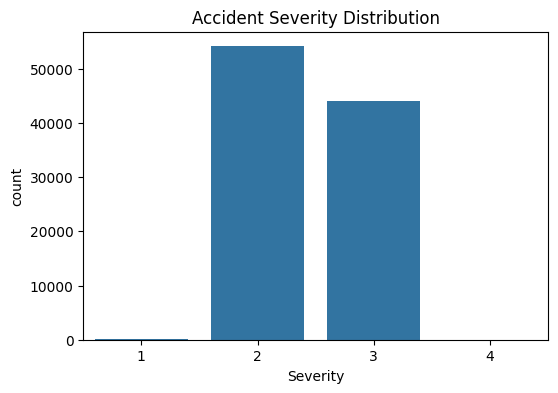

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x='Severity', data=acc)
plt.title("Accident Severity Distribution")
plt.show()


**Interpretation:**

This shows how accident records are distributed across severity levels 1 to 4.
Usually, one or two middle severity classes dominate, meaning the dataset may be imbalanced.

**Step 8: Accidents by hour**

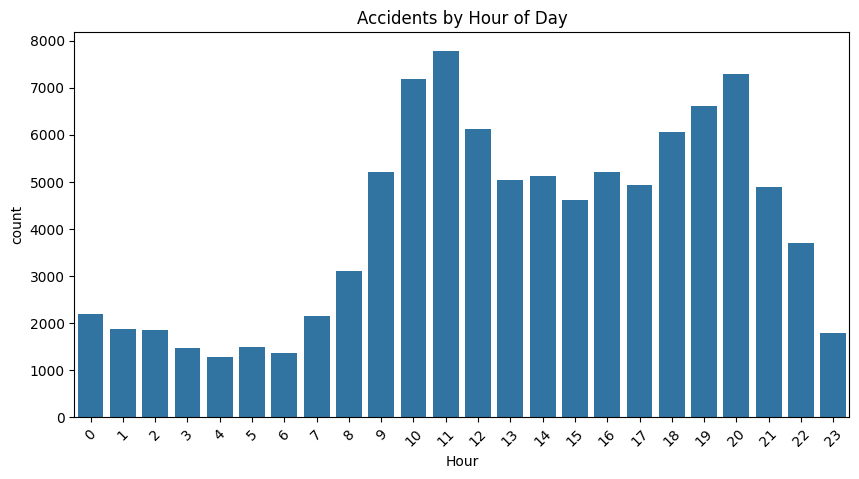

In [20]:
plt.figure(figsize=(10,5))
sns.countplot(x='Hour', data=acc, order=sorted(acc['Hour'].dropna().unique()))
plt.title("Accidents by Hour of Day")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**

This shows how accident records are distributed across severity levels 1 to 4.
Usually, one or two middle severity classes dominate, meaning the dataset may be imbalanced.

**Step 9: Accidents by day of week**

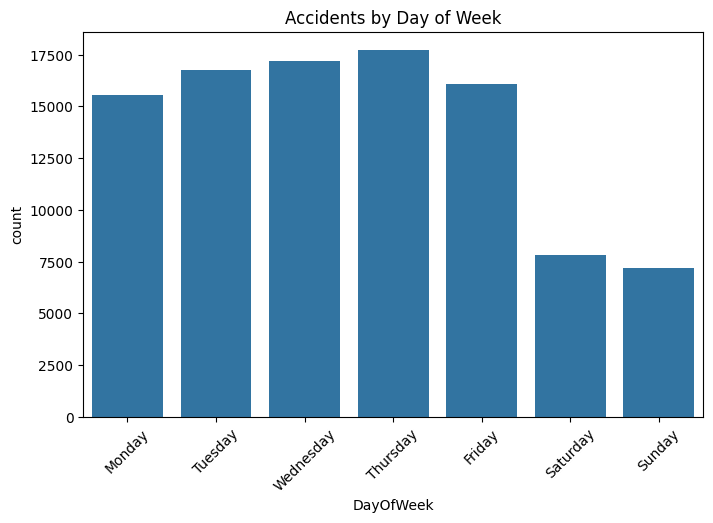

In [21]:
plt.figure(figsize=(8,5))
order_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.countplot(x='DayOfWeek', data=acc, order=order_days)
plt.title("Accidents by Day of Week")
plt.xticks(rotation=45)
plt.show()

**Interpretation:**

This shows whether accidents are more common on working days or weekends.
Higher weekday counts often reflect office commute and denser traffic flow.

**Step 10: Top weather conditions**

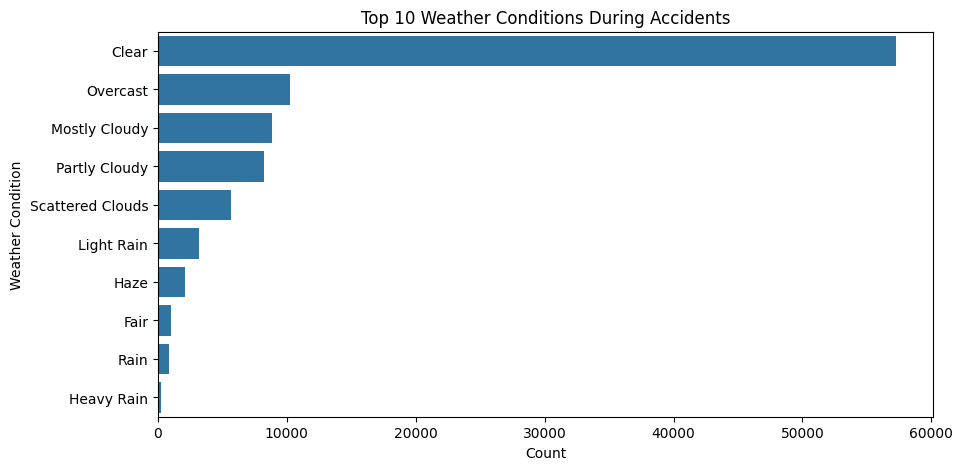

In [23]:
top_weather = acc['Weather_Condition'].value_counts().head(10)


plt.figure(figsize=(10,5))
sns.barplot(x=top_weather.values, y=top_weather.index)
plt.title("Top 10 Weather Conditions During Accidents")
plt.xlabel("Count")
plt.ylabel("Weather Condition")
plt.show()

**Interpretation**

This reveals the weather situations most often associated with reported accidents, such as:



*   Fair
*   Cloudy

*   Rain
*   Fog
Since the dataset explicitly includes weather attributes, it is suitable for studying environmental conditions around accidents.






**Step 11: Severity vs weather**

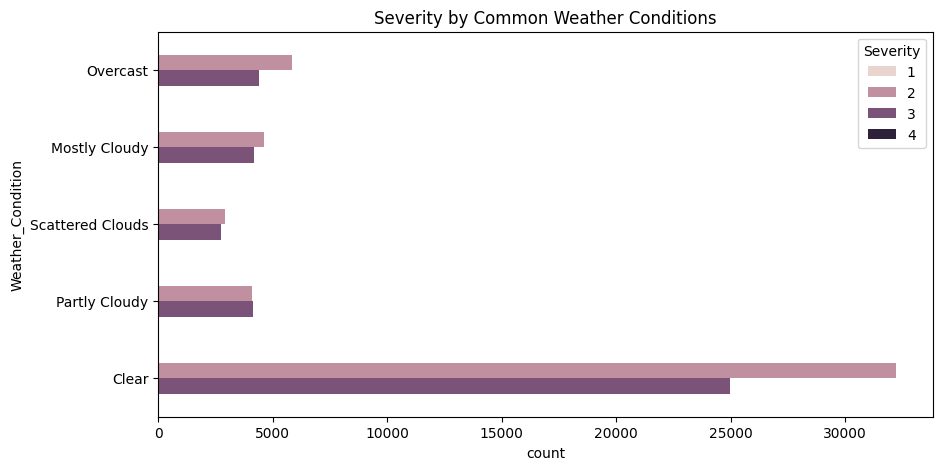

In [24]:
top_conditions = acc['Weather_Condition'].value_counts().head(5).index
weather_filtered = acc[acc['Weather_Condition'].isin(top_conditions)]

plt.figure(figsize=(10,5))
sns.countplot(y='Weather_Condition', hue='Severity', data=weather_filtered)
plt.title("Severity by Common Weather Conditions")
plt.show()

**Interpretation:**

This helps us see whether some weather categories are linked with more severe accidents.
For example, poor visibility or rain-related conditions may show relatively more high-severity cases.

**Step 12: Visibility effect**

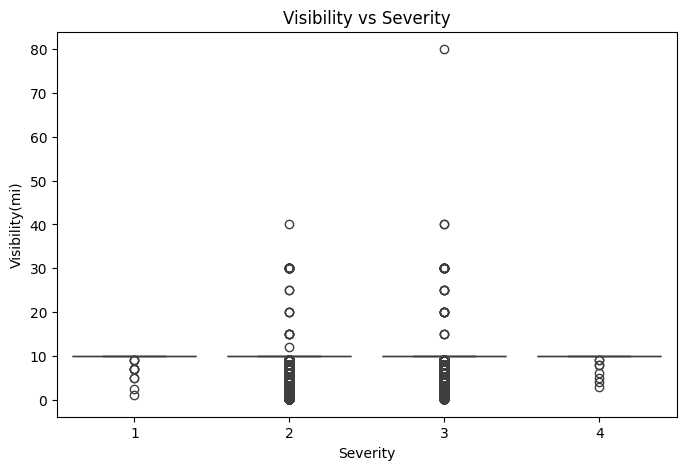

In [25]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Severity', y='Visibility(mi)', data=acc)
plt.title("Visibility vs Severity")
plt.show()

**Interpretation:**

If lower visibility appears more often for higher severity, that suggests reduced visibility may contribute to more serious accidents.
This is an important weather-related factor in road safety analysis.

**Step 13: Temperature effect**

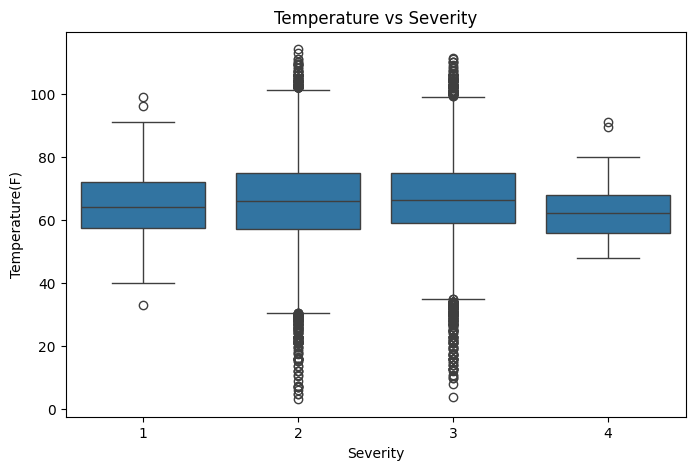

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Severity', y='Temperature(F)', data=acc)
plt.title("Temperature vs Severity")
plt.show()


**Interpretation:**

This checks whether extreme temperature conditions have any visible relationship with severity.
Temperature alone may not always be a strong factor, but it can still support seasonal or weather-related interpretation.

**Step 14: Day/Night effect**

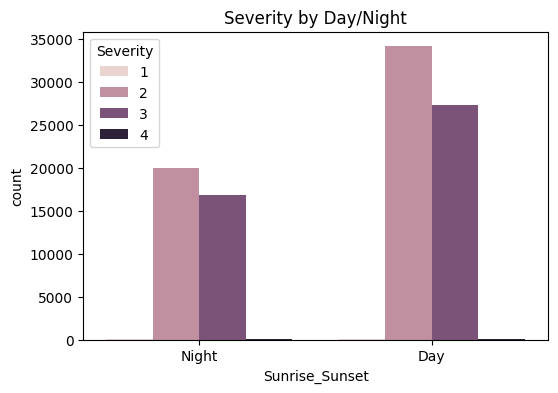

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x='Sunrise_Sunset', hue='Severity', data=acc)
plt.title("Severity by Day/Night")
plt.show()

**Interpretation:**

This helps determine whether night driving is associated with higher severity.
Lower light conditions often increase driving risk, especially when combined with poor weather or visibility.

**Step 15: Road condition features**

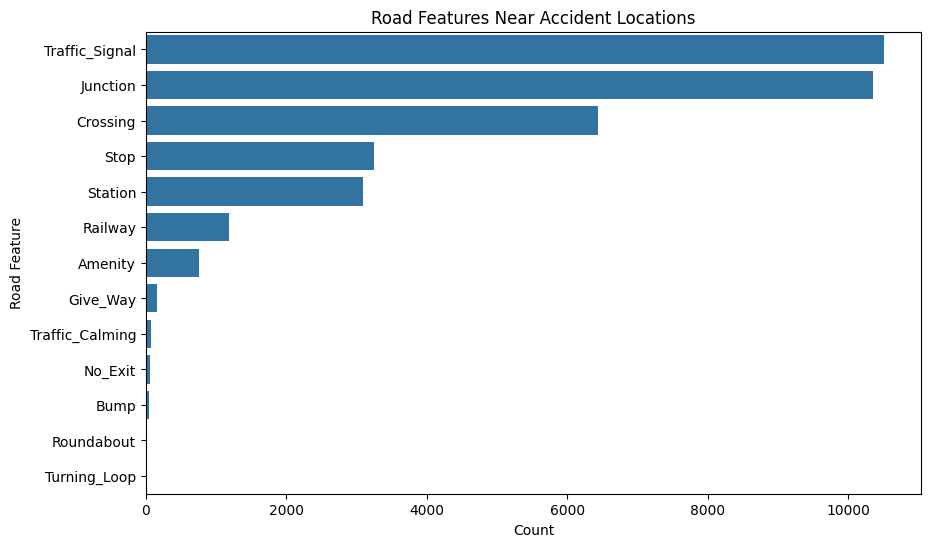

In [28]:
road_features = [
    'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
    'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
    'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop'
]

road_counts = acc[road_features].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=road_counts.values, y=road_counts.index)
plt.title("Road Features Near Accident Locations")
plt.xlabel("Count")
plt.ylabel("Road Feature")
plt.show()

**Interpretation:**

This identifies road conditions and environmental features commonly present near accident locations.
If features like junctions, crossings, or traffic signals appear very frequently, they may represent more accident-prone road contexts.

**Step 16: State-wise hotspot analysis**

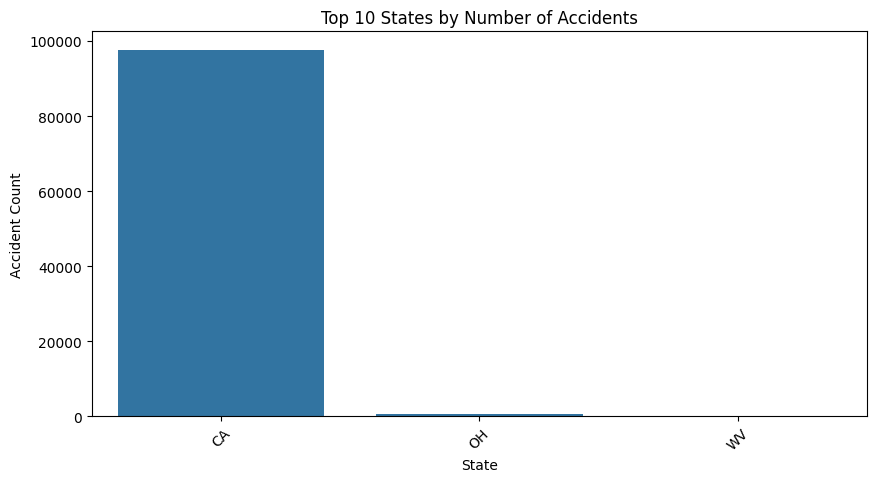

In [29]:
top_states = acc['State'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_states.index, y=top_states.values)
plt.title("Top 10 States by Number of Accidents")
plt.xlabel("State")
plt.ylabel("Accident Count")
plt.xticks(rotation=45)
plt.show()


**Interpretation:**

This shows major geographic hotspots at the state level.
The dataset is broad enough for this because it covers most of the United States rather than one city or one state.

**Step 17: City-wise hotspot analysis**

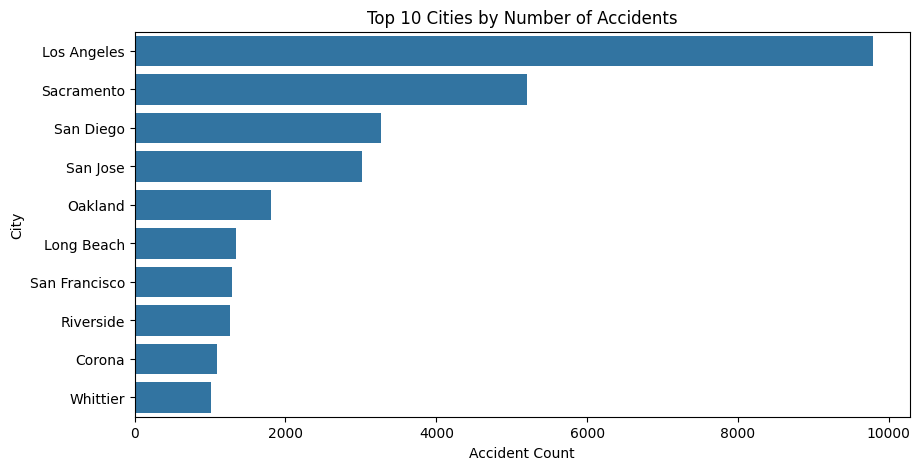

In [30]:
top_cities = acc['City'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 10 Cities by Number of Accidents")
plt.xlabel("Accident Count")
plt.ylabel("City")
plt.show()

**Interpretation**

This gives finer hotspot insight.
Cities with dense traffic, complex road networks, or large populations often appear more often.

**Step 18: Correlation heatmap**

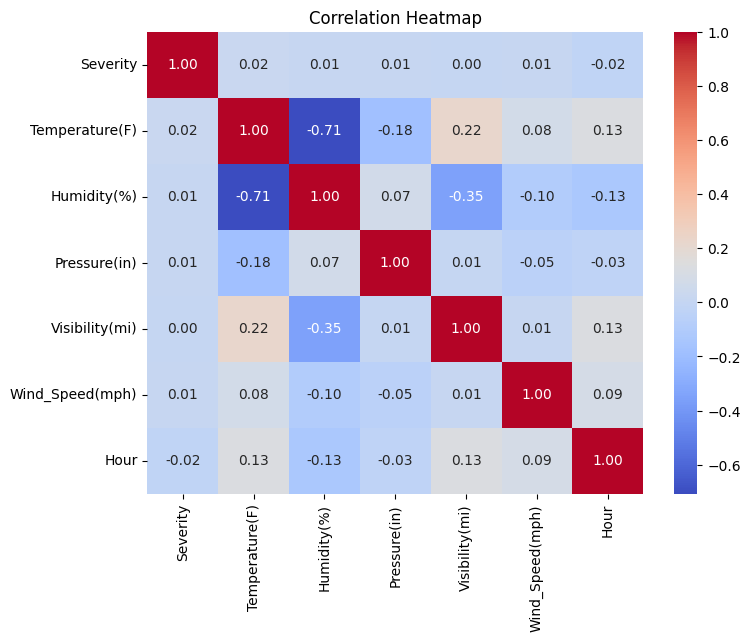

In [31]:
corr_cols = ['Severity', 'Temperature(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Hour']
corr = acc[corr_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Interpretation:**

The heatmap helps detect which numeric variables move together.
A weak correlation does not mean the variable is unimportant, but it suggests the relationship may be nonlinear or influenced by multiple factors together.

**Step 19: Optional hotspot scatter plot (sample for speed)**

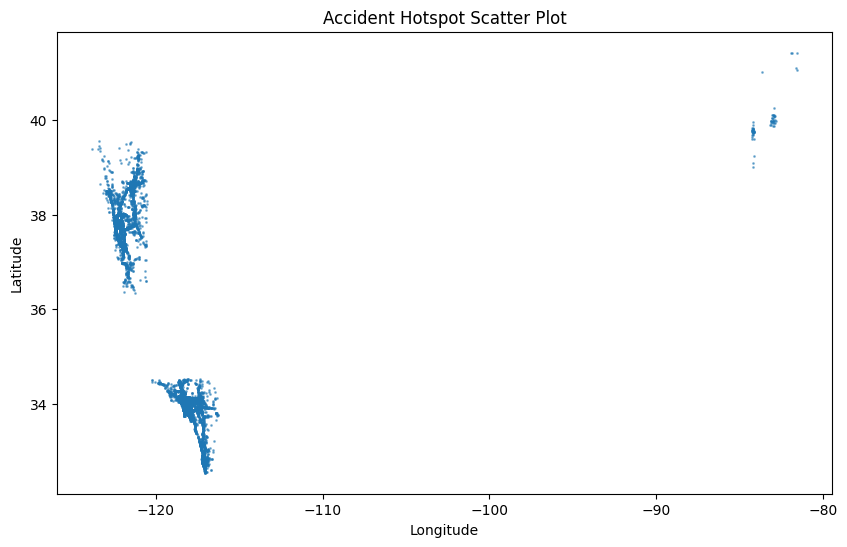

In [32]:
sample_acc = acc.sample(min(10000, len(acc)), random_state=42)

plt.figure(figsize=(10,6))
plt.scatter(sample_acc['Start_Lng'], sample_acc['Start_Lat'], s=1, alpha=0.5)
plt.title("Accident Hotspot Scatter Plot")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Interpretation:**

This provides a simple hotspot visualization.
Dense clusters indicate areas with frequent accidents and can support traffic planning or road safety interventions.

# **Conclusion**


In this task, I analyzed the US Accidents dataset to identify traffic accident patterns related to weather, road conditions, and time of day. After cleaning the data and extracting time features, I visualized accident severity, hourly trends, weekday patterns, weather conditions, and road-feature frequencies. I also identified hotspot states and cities and created a geographic scatter plot of accident locations. The analysis shows that accident occurrence can vary with traffic timing, environmental conditions such as visibility and weather, and road contexts such as junctions and crossings. This makes the dataset useful for understanding accident-prone conditions and supporting traffic safety planning.